<a href="https://colab.research.google.com/github/vaishnavibhosale727-dotcom/CodeAlpha_WebScraping/blob/main/webscraping1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Web Scraping + Data Visualization Project
End-to-end data pipeline using Python**

**part 1 : Web Scraping**

In this section, we collect book data from the website using requests and BeautifulSoup.

In [ ]:
!pip install beautifulsoup4
!pip install requests

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

url = "http://books.toscrape.com/"
response = requests.get(url)
soup = BeautifulSoup(response.text, "html.parser")

books = soup.find_all("article", class_="product_pod")

titles = []
prices = []
ratings = []

for book in books:
    title = book.h3.a["title"]
    price = book.find("p", class_="price_color").text
    rating = book.find("p", class_="star-rating")["class"][1]

    titles.append(title)
    prices.append(price)
    ratings.append(rating)

df = pd.DataFrame({
    "Title": titles,
    "Price": prices,
    "Rating": ratings
})

df.head()

,Title,Price,Rating
0,A Light in the Attic,Â£51.77,Three
1,Tipping the Velvet,Â£53.74,One
2,Soumission,Â£50.10,One
3,Sharp Objects,Â£47.82,Four
4,Sapiens: A Brief History of Humankind,Â£54.23,Five


In [ ]:
df

,Title,Price,Rating
0,A Light in the Attic,Â£51.77,Three
1,Tipping the Velvet,Â£53.74,One
2,Soumission,Â£50.10,One
3,Sharp Objects,Â£47.82,Four
4,Sapiens: A Brief History of Humankind,Â£54.23,Five
5,The Requiem Red,Â£22.65,One
6,The Dirty Little Secrets of Getting Your Dream...,Â£33.34,Four
7,The Coming Woman: A Novel Based on the Life of...,Â£17.93,Three
8,The Boys in the Boat: Nine Americans and Their...,Â£22.60,Four
9,The Black Maria,Â£52.15,One


In [ ]:
df.to_csv("books_data.csv", index=False)

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

titles = []
prices = []
ratings = []

# Loop through 50 pages
for page in range(1, 51):
    url = f"http://books.toscrape.com/catalogue/page-{page}.html"
    response = requests.get(url)
    soup = BeautifulSoup(response.text, "html.parser")

    books = soup.find_all("article", class_="product_pod")

    for book in books:
        title = book.h3.a["title"]
        price = book.find("p", class_="price_color").text
        rating = book.find("p", class_="star-rating")["class"][1]

        titles.append(title)
        prices.append(price)
        ratings.append(rating)

df_all = pd.DataFrame({
    "Title": titles,
    "Price": prices,
    "Rating": ratings
})

In [ ]:
df_all['Price'] = df_all['Price'].str.replace('Â£','').astype(float)


In [ ]:
rating_dict = {'One':1, 'Two':2, 'Three':3, 'Four':4, 'Five':5}
df_all['Rating'] = df_all['Rating'].map(rating_dict)


In [ ]:
df_all.head()

,Title,Price,Rating
0,A Light in the Attic,51.77,3
1,Tipping the Velvet,53.74,1
2,Soumission,50.10,1
3,Sharp Objects,47.82,4
4,Sapiens: A Brief History of Humankind,54.23,5


In [ ]:
df_all['Price'] = df_all['Price'].astype(str)


In [ ]:
df_all['Price'] = df_all['Price'].str.replace('Â£','').astype(float)


In [ ]:
df_all.head()

,Title,Price,Rating
0,A Light in the Attic,51.77,3
1,Tipping the Velvet,53.74,1
2,Soumission,50.10,1
3,Sharp Objects,47.82,4
4,Sapiens: A Brief History of Humankind,54.23,5


In [ ]:
rating_dict = {'One':1, 'Two':2, 'Three':3, 'Four':4, 'Five':5}
df_all['Rating'] = df_all['Rating'].map(rating_dict)

In [ ]:
df_all.head()

,Title,Price,Rating
0,A Light in the Attic,51.77,NaN
1,Tipping the Velvet,53.74,NaN
2,Soumission,50.10,NaN
3,Sharp Objects,47.82,NaN
4,Sapiens: A Brief History of Humankind,54.23,NaN


In [ ]:
df_all.isnull().sum()

,0
Title,0
Price,0
Rating,1000


In [ ]:
df_all.duplicated().sum()

np.int64(0)

In [ ]:
import os
os.listdir()

['.config', 'books_data.csv', 'sample_data']

In [ ]:
import pandas as pd


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df.to_csv("books_all_pages.csv", index=False)

In [ ]:
df_all.describe()

,Price,Rating
count,1000.00000,0.0
mean,35.07035,NaN
std,14.44669,NaN
min,10.00000,NaN
25%,22.10750,NaN
50%,35.98000,NaN
75%,47.45750,NaN
max,59.99000,NaN


 **part 2 :- Data Visualization**

In this section, we analyze and visualize the dataset using Matplotlib.


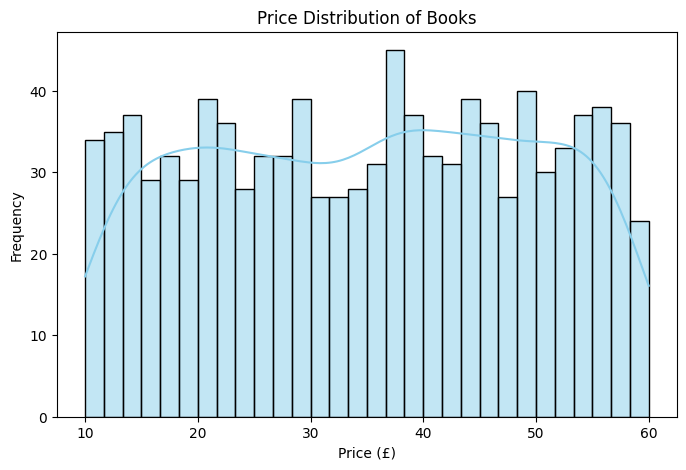

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df_all['Price'], bins=30, kde=True, color='skyblue')
plt.title("Price Distribution of Books")
plt.xlabel("Price (£)")
plt.ylabel("Frequency")
plt.show()

/tmp/ipython-input-1630086772.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Rating', data=df_all, palette='viridis')
/tmp/ipython-input-1630086772.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.countplot(x='Rating', data=df_all, palette='viridis')


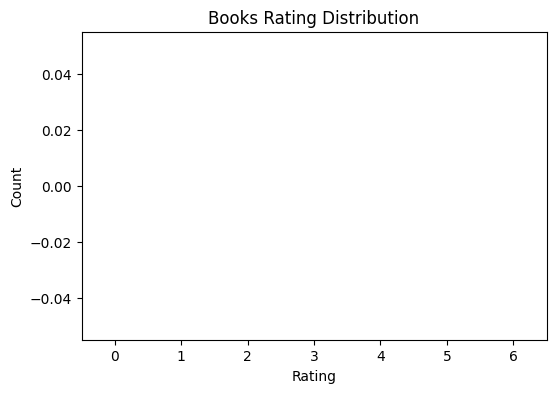

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Rating', data=df_all, palette='viridis')
plt.title("Books Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

In [ ]:
top10 = df_all.sort_values(by='Price', ascending=False).head(10)



/tmp/ipython-input-2969671884.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Price', y='Title', data=top10, palette='magma')


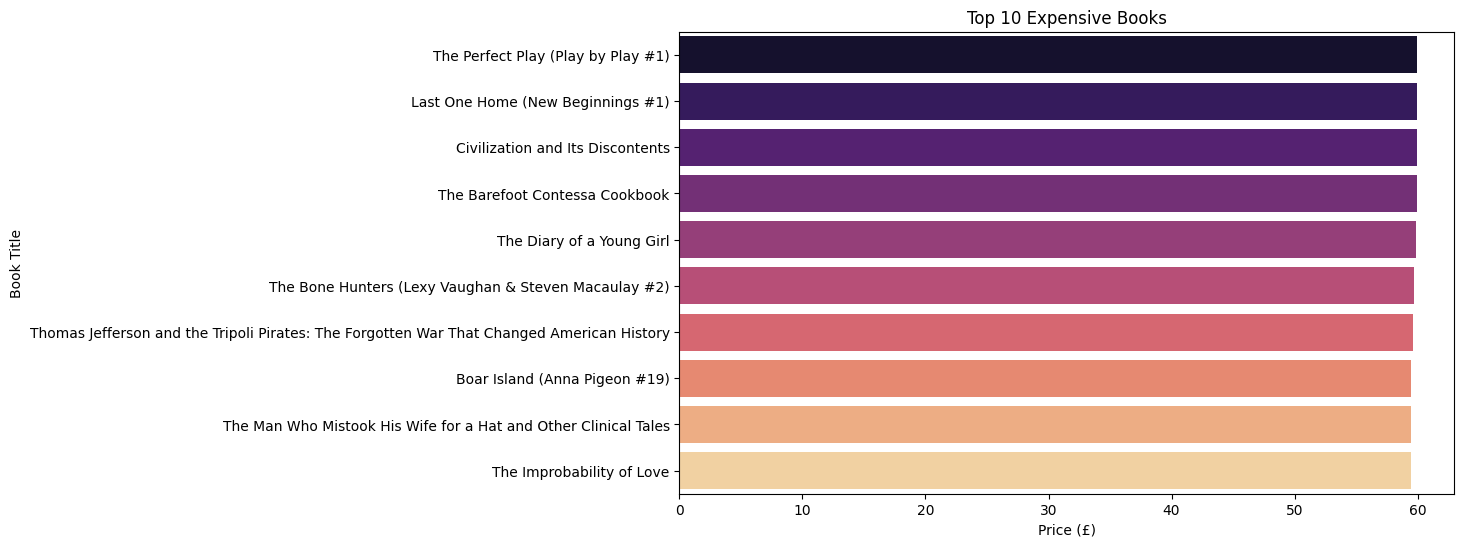

In [ ]:
top10 = df_all.sort_values(by='Price', ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x='Price', y='Title', data=top10, palette='magma')
plt.title("Top 10 Expensive Books")
plt.xlabel("Price (£)")
plt.ylabel("Book Title")
plt.show()

In [ ]:
!pip install PyGithub

In [ ]:
import os
os.listdir()

['.config', 'books_all_pages.csv', 'books_data.csv', 'drive', 'sample_data']

In [ ]:
['sample_data', 'books_all_pages.csv']

['sample_data', 'books_all_pages.csv']

 **Conclusion - Web Scraping & Data Visualization**


This project successfully demonstrates an end-to-end data analysis process, starting from web scraping to data visualization.
Book data was extracted from multiple web pages using Python and converted into a structured dataset.
The collected data was cleaned and transformed using Pandas for accurate analysis.
Exploratory Data Analysis was performed to understand trends in price and ratings.
Visualizations were created using Matplotlib to present insights in a clear and meaningful way.
The project highlights practical skills in data extraction, preprocessing, and visualization.
Overall, it reflects a complete real-world data pipeline relevant to Data Science and Analytics roles. 🚀

- Successfully scraped data from multiple pages
- Cleaned and structured dataset
- Performed exploratory data analysis
- Generated meaningful visualizations

[link text](https://)